# Student Employability Analysis and Placement Prediction


## 1. Objective
The goal of this project is to analyze student data and identify factors that influence placement outcomes. Later, a machine learning model will be developed to predict whether a student is likely to be placed. 

In [2]:
#Imprting libraries
import pandas as pd
import numpy as np
import seaborn as sns

## 2. Loading the Dataset

In [3]:
df = pd.read_csv("placementdata.csv")
df.head()


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


## 3. Dataset Overview 
The dataset contains academic, skilled-based, and extracurricular information about students along with their placement status.

In [4]:
df.shape

(10000, 12)

In [5]:
df.columns

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  str    
 8   PlacementTraining          10000 non-null  str    
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  str    
dtypes: float64(2), int64(7), str(3)
memory usage: 937.6 KB


In [7]:
df.describe()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


## 4. Data Quality Assessment

In [8]:
df.isnull().sum()

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

#### Dataset Overview
The Dataset contains 10,000 student records and 12 columns.<br>
There are no missing values were found.<br>
The target column is Placement_Status, which indicates whether a student was placed or not placed. <br>
The dataset contains academic, skill-based, and training-related attributes such as CGPA, internships, projects, aptitude scores, and soft skills ratings. Most features are numerical.<br>

## 5. Target Variable Analysis
### Placement Status Distribution

In [10]:
df["PlacementStatus"].value_counts()

PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64

##### *Observation* 
The dataset contains **10,000 student** records.<br>
- **5,803 students** were not placed.<br>
- **4,197 students** were placed.<br>
The target value is moderately inbalanced, with approximately **58%** of students not placed and **42%** placed. However, the imbalance is not severe enough to prevent building machine learning model.


In [11]:
df["PlacementStatus"].value_counts(normalize=True)*100

PlacementStatus
NotPlaced    58.03
Placed       41.97
Name: proportion, dtype: float64

 
Visualizing the number of placed and non-placed students.

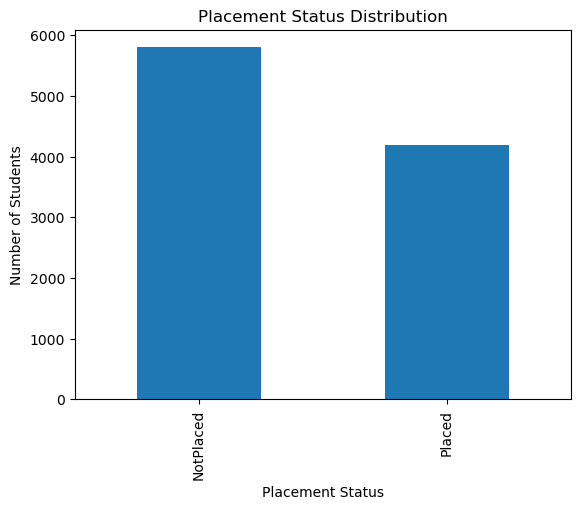

In [12]:
import matplotlib.pyplot as plt
df["PlacementStatus"].value_counts().plot(kind="bar")
plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

## 6. Feature-wise Analysis
### 6.1 CGPA Analysis
Analyzing the relationship between CGPA and placement status.

In [13]:
df.groupby("PlacementStatus")["CGPA"].mean()

PlacementStatus
NotPlaced    7.467672
Placed       8.016488
Name: CGPA, dtype: float64

##### Observation 
Students who were placed have a higher average CGPA (8.02) compared to students who were not placed (7.47). <br>
This suggests that academic performance may have a positive influence on placement outcomes.

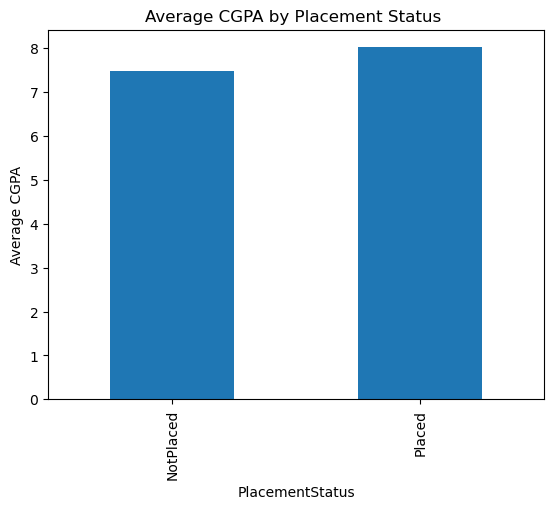

In [14]:
df.groupby("PlacementStatus")["CGPA"].mean().plot(kind="bar")
plt.title("Average CGPA by Placement Status ")
plt.ylabel("Average CGPA")
plt.show()

### 6.2 Internship Analysis

In [15]:
df.groupby("PlacementStatus")["Internships"].mean()

PlacementStatus
NotPlaced    0.901775
Placed       1.253038
Name: Internships, dtype: float64

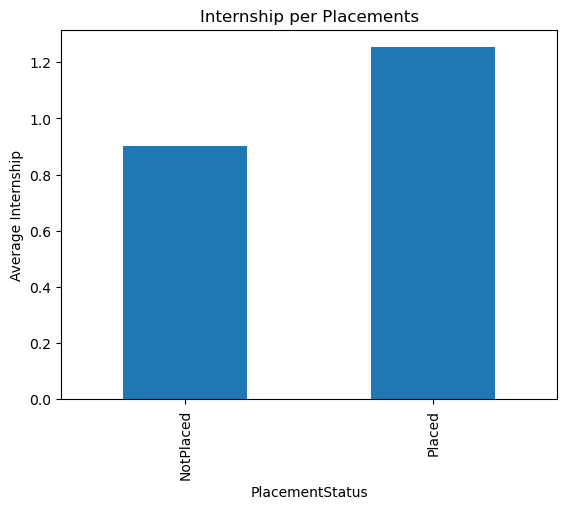

In [16]:
df.groupby("PlacementStatus")["Internships"].mean().plot(kind="bar")
plt.title("Internship per Placements")
plt.ylabel("Average Internship")
plt.show()

## 7. Univariate Analysis
Univariate analysis focuses on examining one variable at a time to understand its distribution, spread, central tendency, and presence of outliers. This step helps identify unusual patterns and provides insights into the characteristics of individual features before studying relationships between multiple variables.

- Understand the distribution of each feature.
- Detect skewness in the data.
- Identify potential outliers.
- Understand the variability of numerical features.
- Prepare the dataset for machine learning.

### 7.1 Distribution of CGPA 
CGPA is one of the most influential academic indicators in student placement prediction. Analyzing its distribution helps us understand the academic performance of students and identify whether the values are normally distributed, skewed, or contain any unusual observations.

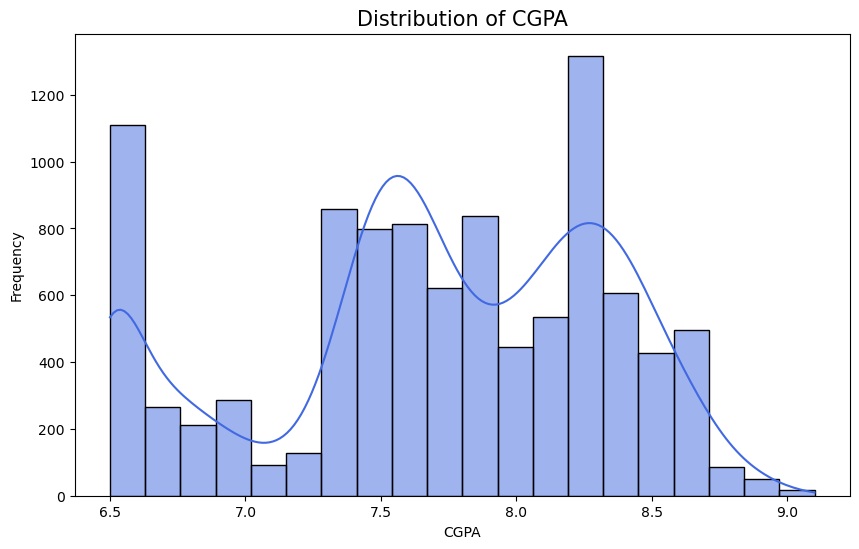

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x='CGPA',
    kde="True",
    bins=20,
    color='royalblue'
)
plt.title("Distribution of CGPA", fontsize=15)
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()

##### *Observation*

- The CGPA values range approximately from **6.5** to **9.1**, indicating realistic academic scores.
- Most students have CGPA values between **7.4** and **8.5**, suggesting that the majority of students have good academic performance.
- The distribution is not perfectly normal and appears to have multiple regions where values are concentrated.
- Overall, the CGPA feature appears to be well-distributed and suitable for further exploratory analysis and machine learning.
  

### 7.2 Outlier Detection of CGPA 
After understanding the distribution of CGPA, it is important to identify whether the dataset contains any outliers. Outliers are observations that differ significantly from the majority of the data and may affect statistical analysis and machine learning models.
A box plot provides a simple visual representation of the spread of data and helps identify potential outliers using the Interquartile Range (IQR) method [IQR=Q3-Q1].

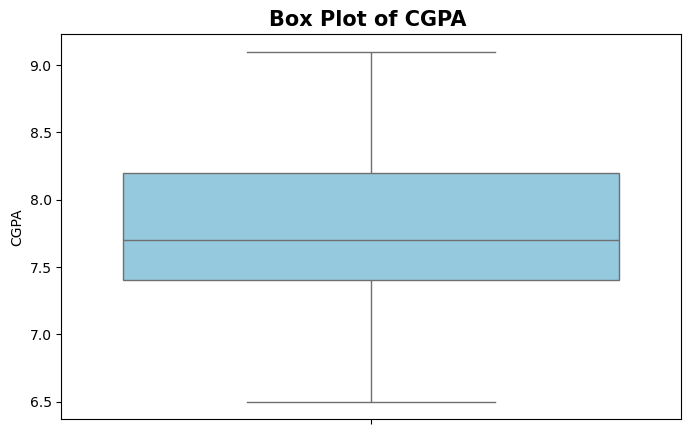

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(
    y=df['CGPA'],
    color='skyblue'
    )
plt.title("Box Plot of CGPA ", fontsize=15, fontweight='bold')
plt.ylabel("CGPA")
plt.show()

### 7.3 Aptitude Test Score Analysis
The aptitude test score measures a student's problem-solving and analytical abilities. Analyzing its distribution helps identify score patterns, detect outliers, and understand whether aptitude is likely to influence placement outcomes.


#### Histogram

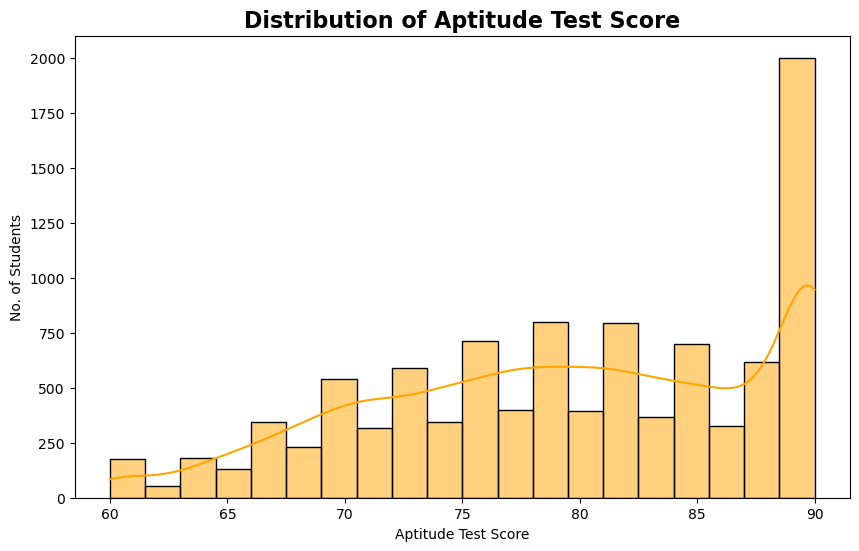

In [19]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x='AptitudeTestScore',
    kde=True,
    bins=20,
    color="orange"
)
plt.title("Distribution of Aptitude Test Score", fontsize=16, fontweight='bold')
plt.xlabel("Aptitude Test Score")
plt.ylabel("No. of Students")

plt.show()

####  Box plot

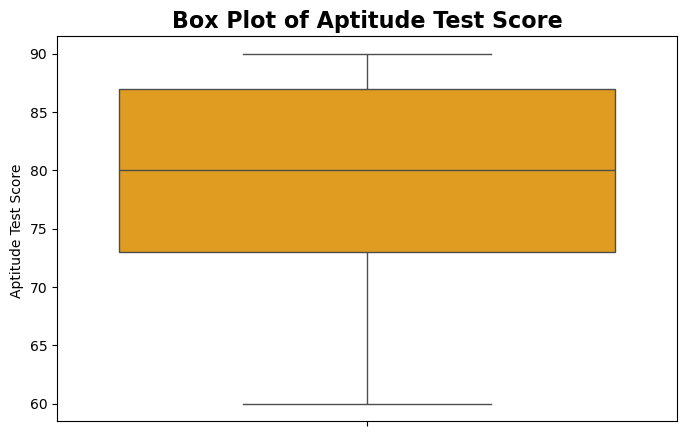

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(
    y=df["AptitudeTestScore"],
    color='orange'
)
plt.title("Box Plot of Aptitude Test Score", fontsize=16, fontweight='bold')
plt.ylabel("Aptitude Test Score ")

plt.show()

### 7.4 Soft Skills Rating Analysis
Soft skills such as communication, teamwork, and leadership often influence placement distribution and spread of soft skill ratings among students

#### Histogram

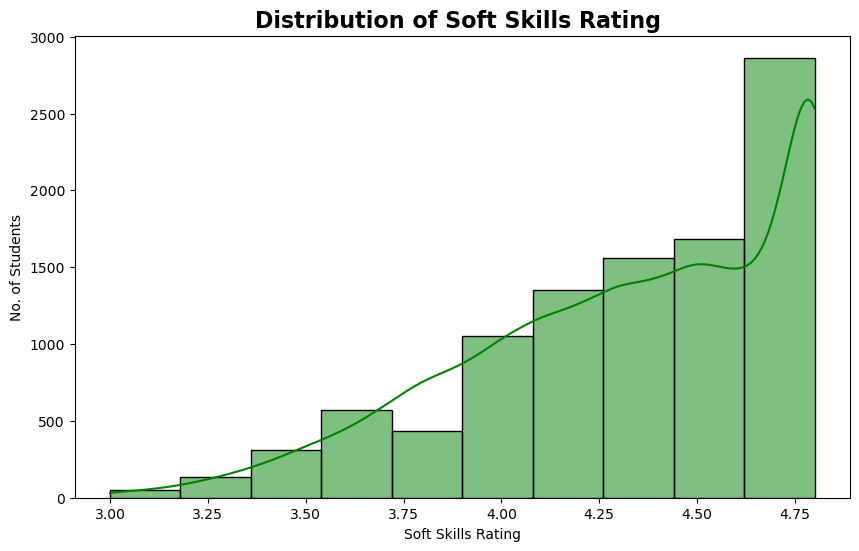

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x=df["SoftSkillsRating"],
    kde='True',
    bins=10,
    color='green'
)
plt.title("Distribution of Soft Skills Rating ", fontsize=16 , fontweight='bold')
plt.xlabel("Soft Skills Rating")
plt.ylabel("No. of Students")
plt.show()

#### Box plot

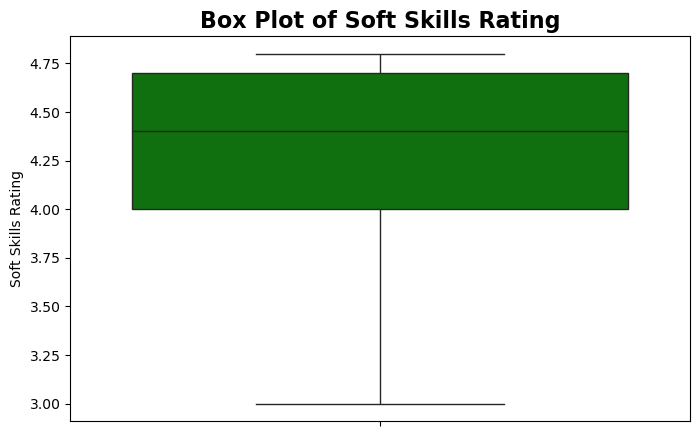

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(
    y=df["SoftSkillsRating"],
    color='green'
)
plt.title("Box Plot of Soft Skills Rating", fontsize=16, fontweight='bold')
plt.ylabel("Soft Skills Rating")
plt.show()

##### *Observation* 

- The Soft Skills Rating ranges approximately from **3.0 to 4.8**, indicating that students generally possess moderate to high soft skill ratings.
- Most students have ratings between **4.0 and 4.8**, suggesting that a large proportion of students demonstrate strong communication and interpersonal skills.
- The histogram shows a slight negative (left) skew, indicating that higher soft skill ratings are more common than lower ratings.
- The box plot does not display any significant outliers, suggesting that the data is consistent and free from extreme observations.
- The median soft skills rating is around **4.4**, indicating that at least half of the students have relatively high soft skill ratings.

##### *Conclusion*
The Soft Skills Rating feature is well distributed and does not contain significant outliers. Therefore, it is suitable for further analysis and machine learning without requiring outlier treatment.

### 7.5 Remaining Features
The remaining numerical features exhibit reasonable distributions without obvious anomalies.These features will be evaluated during correlation analysis and model training to determine their contribution to placement prediction.

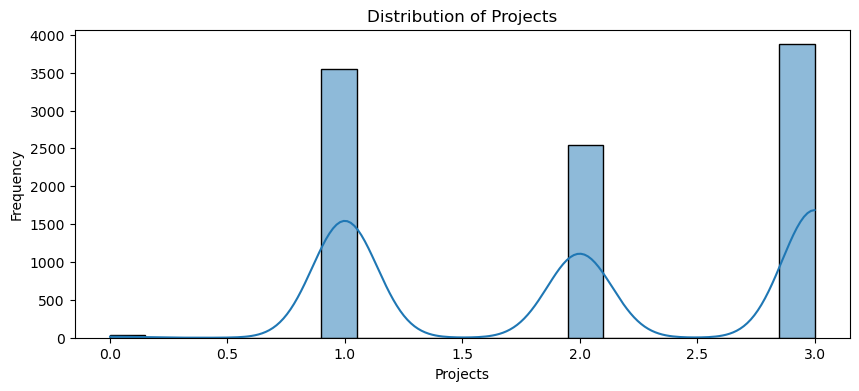

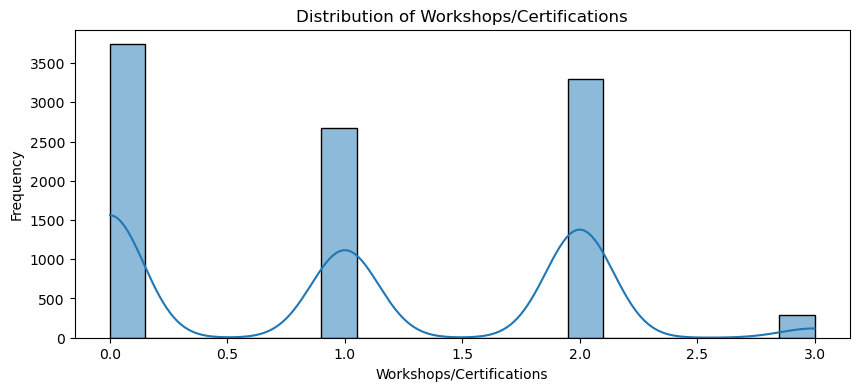

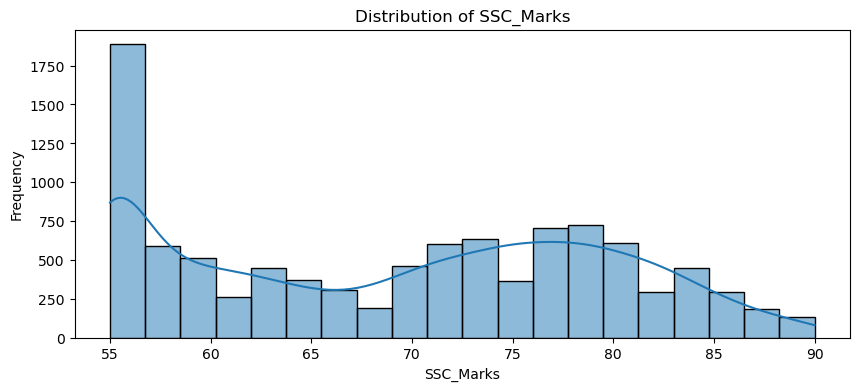

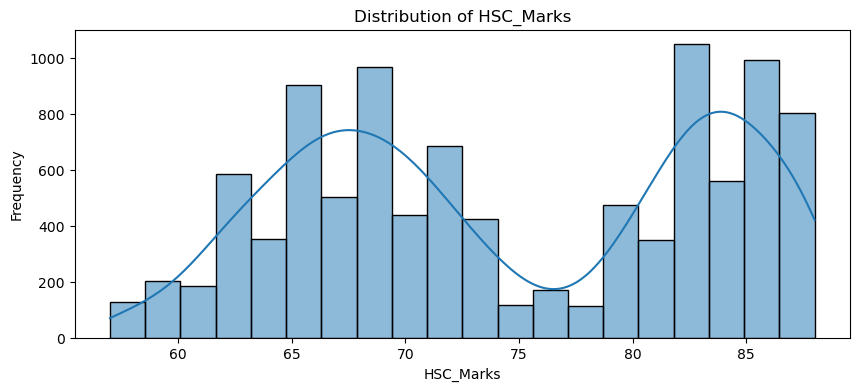

In [23]:
features=[
    'Projects',
    'Workshops/Certifications',
    'SSC_Marks',
    'HSC_Marks'
]

for feature in features:
    plt.figure(figsize=(10,4))

    sns.histplot(df[feature],kde=True,bins=20)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

##### *Observation*

- The remaining numerical features, namely **Projects, Workshops/Certifications, SSC Marks, and HSC Marks**, exhibit reasonable distributions with no obvious anomalies.
- The Projects feature is concentrated around discrete values, reflecting the limited number of projects completed by students.
- Workshops/Certifications also display discrete distributions, indicating varying levels of participation among students.
- SSC Marks and HSC Marks show a wider spread of academic performance across students without any unrealistic values.
- Overall, these features appear suitable for further analysis and machine learning model development.

##### *Conclusion*

The remaining numerical features exhibit meaningful variability and do not show any obvious data quality concerns. Their predictive importance will be further evaluated during correlation analysis and machine learning model training.

## 8. Correlation Analysis 
Correlation analysis measures the strength and direction of relationships between numerical variables. It helps identify highly related features and detect muticollinearity before model training.

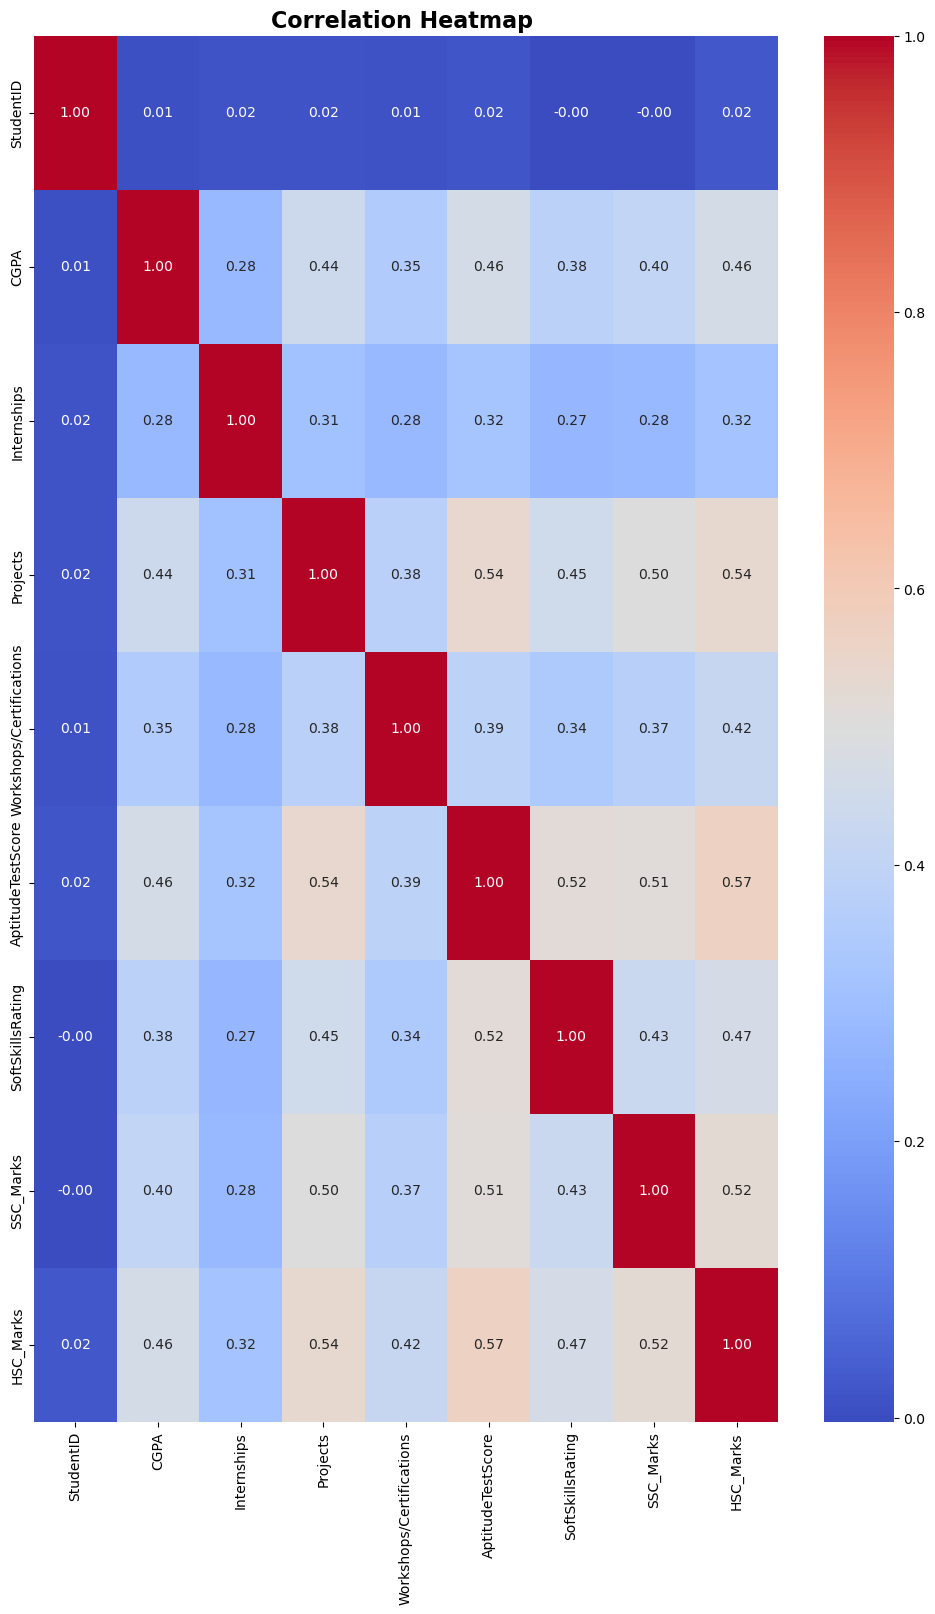

In [24]:
numerical_df=df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(12,18))
sns.heatmap(
numerical_df.corr(),
cmap='coolwarm',
annot=True,
fmt=".2f",
)
plt.title("Correlation Heatmap ",fontsize=16, fontweight='bold')



plt.show()

##### *Observation*

- The correlation heatmap illustrates the strength and direction of relationships between the numerical features in the dataset.
- Most feature pairs exhibit **weak to moderate positive correlations**, indicating that while they are related, they do not provide identical information.
- The highest positive correlation is observed between **HSC Marks** and **Workshops/Certifications** (approximately **0.57**), suggesting that students with better academic performance in higher secondary education tend to participate more in workshops and certifications.
- **Projects** also show moderate positive correlations with **Workshops/Certifications (0.54)** and **HSC Marks (0.54)**, indicating that academically active students are also more engaged in practical learning activities.
- **Soft Skills Rating** has a moderate positive correlation with **Workshops/Certifications (0.52)**, suggesting that students participating in workshops may also develop stronger interpersonal and communication skills.
- No feature pair exhibits a correlation coefficient greater than **0.8**, indicating the absence of severe multicollinearity among the numerical variables.

##### *Conclusion*

The numerical features exhibit meaningful but not excessive correlations. Therefore, no feature needs to be removed due to multicollinearity at this stage, and all numerical variables can be considered for machine learning model development.

## 9. Categorical Feature Analysis 

Categorical feature analysis helps understand how different categories influence the target variable (Placement Status). Unlike numerical variables, categorical variables are analyzed by comparing the frequency of each category and observing their relationship with placement outcomes.


### 9.1 Placement Training VS Placement Status

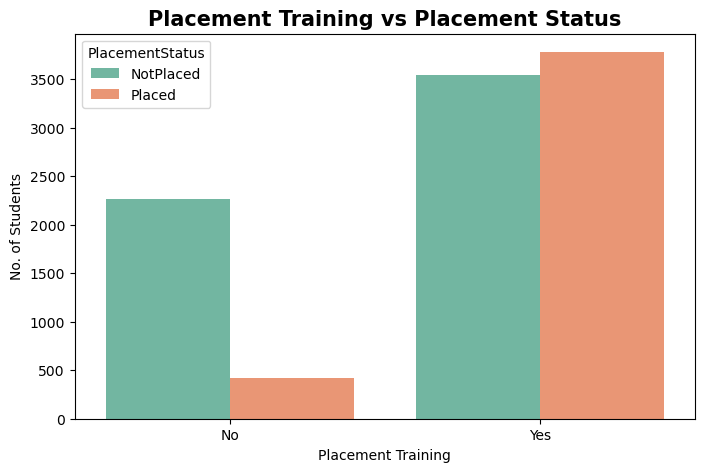

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='PlacementTraining',
    hue='PlacementStatus',
    palette='Set2'
)
plt.title("Placement Training vs Placement Status", fontsize=15, fontweight='bold')
plt.xlabel("Placement Training")
plt.ylabel("No. of Students")
plt.show()

##### *Observation*

- Students who **did not participate** in placement training have a significantly higher number of **Not Placed** outcomes compared to **Placed** outcomes.
- Among students who **participated** in placement training, the number of **Placed** students is slightly higher than the number of **Not Placed** students.
- The graph suggests a positive association between participation in placement training and successful placements.
- Placement training appears to improve students' chances of securing placements, although it is not the only factor influencing placement outcomes.

##### *Conclusion*

Placement Training appears to be an important categorical feature influencing placement outcomes and should be retained as an input feature for the machine learning model.

### 9.2 Extracurricular Activities


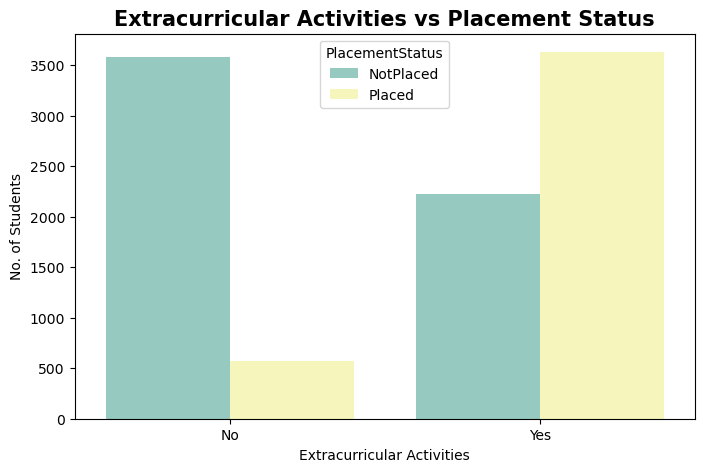

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='ExtracurricularActivities',
    hue='PlacementStatus',
    palette='Set3'
)
plt.title("Extracurricular Activities vs Placement Status", fontsize=15,fontweight='bold')
plt.xlabel("Extracurricular Activities")
plt.ylabel("No. of Students")
plt.show()


##### *Observation*

- Students who **did not participate** in extracurricular activities show a much higher number of **Not Placed** outcomes.
- Among students who **participated** in extracurricular activities, the number of **Placed** students is considerably higher than the number of **Not Placed** students.
- The graph indicates a positive relationship between participation in extracurricular activities and placement success.
- Students involved in extracurricular activities tend to achieve better placement outcomes, possibly due to improved communication, leadership, teamwork, and confidence.

##### *Conclusion*

Extracurricular Activities appear to be a meaningful categorical feature and may contribute positively to predicting placement outcomes in the machine learning model.

## 10. Bivariate Analysis 
Bivariate analysis examines the relationship between two numerical variables while considering the target variable. It helps identify patterns, clusters, and the degree of seperation between placed and non-placed students, providing insights into feature interactions before machine learning model development.

### 10.1 CGPA vs Aptitude Test Score


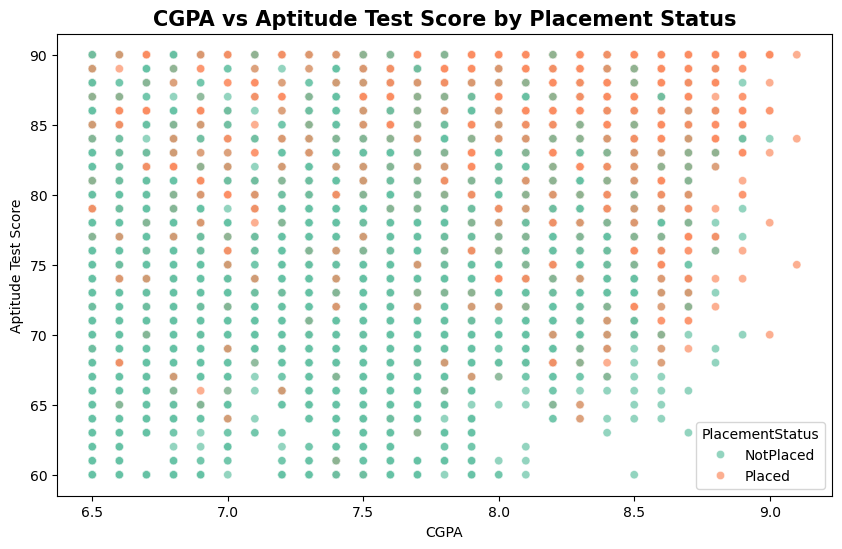

In [27]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='CGPA',
    y='AptitudeTestScore',
    hue='PlacementStatus',
    alpha=0.7,
    palette='Set2'
)

plt.title("CGPA vs Aptitude Test Score by Placement Status", fontsize=15, fontweight='bold')
plt.xlabel("CGPA")
plt.ylabel("Aptitude Test Score")
plt.show()

##### Observation

- The scatter plot shows the relationship between **CGPA** and **Aptitude Test Score**, with points colored according to placement status.
- Students with **higher CGPA (above approximately 8.0)** and **higher aptitude scores (above approximately 80)** are more frequently placed.
- Students with lower CGPA and aptitude scores have a comparatively higher proportion of non-placed outcomes.
- Although there is some overlap between the two classes, placed students are more concentrated in the upper-right region of the graph.
- This indicates that both CGPA and aptitude score together may contribute positively to predicting placement outcomes.

##### Conclusion

CGPA and Aptitude Test Score demonstrate a positive relationship with placement outcomes. These features should be retained as important predictors for the machine learning model.

### 10.2 Projects vs Internships


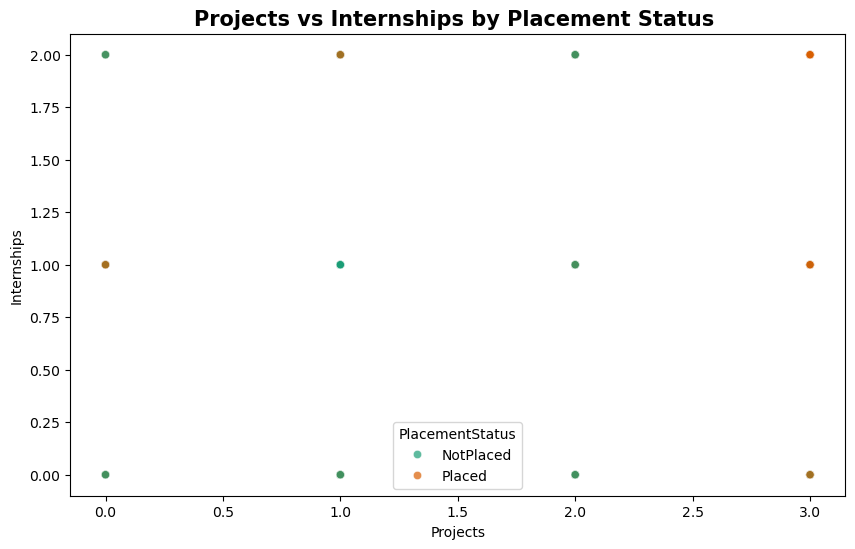

In [28]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Projects',
    y='Internships',
    hue='PlacementStatus',
    alpha=0.7,
    palette='Dark2'
)
plt.title("Projects vs Internships by Placement Status ",fontsize=15, fontweight='bold')
plt.xlabel("Projects")
plt.ylabel("Internships")
plt.show()

##### *Observation*

- The scatter plot compares the number of projects completed with the number of internships undertaken by students.
- Since both variables contain only a few discrete values, many observations overlap at the same coordinates.
- Students with a higher number of projects and internships appear to have a greater proportion of placements.
- However, the overlap between placed and non-placed students indicates that these features alone are not sufficient to determine placement outcomes.
- Projects and internships should be considered alongside academic performance and skill-based features when building the prediction model.

##### *Conclusion*

Projects and internships provide useful information for placement prediction, but they should be used together with other academic and skill-related features to improve model performance.

## 11. Key-Insights
The exploratory data analysis provided several valuable insights into the student placement dataset:

1. **Data Quality**
   - The dataset contains no significant missing values or duplicate records, making it suitable for machine learning without extensive cleaning.

2. **Academic Performance**
   - Students with higher CGPA generally exhibit a higher placement rate.
   - Both SSC and HSC marks show positive relationships with other academic and skill-based features.

3. **Skill-Based Features**
   - Higher aptitude scores and stronger soft skills are associated with better placement outcomes.
   - Most students possess moderate to high soft skill ratings, indicating a generally skilled student population.

4. **Practical Experience**
   - Students participating in more projects, internships, and workshops tend to demonstrate stronger placement outcomes.
   - These features complement academic performance rather than replacing it.

5. **Categorical Features**
   - Placement training appears to positively influence placement success.
   - Participation in extracurricular activities is also associated with a higher number of placed students.

6. **Correlation Analysis**
   - Most numerical variables exhibit weak to moderate positive correlations.
   - No severe multicollinearity was observed, allowing all numerical features to be retained for model development.

7. **Overall Finding**
   - Student placement is influenced by a combination of academic performance, practical experience, technical aptitude, and soft skills rather than any single feature.

## 13. EDA Summary

The Exploratory Data Analysis (EDA) successfully examined the structure, quality, and characteristics of the student placement dataset. Data quality assessment confirmed that the dataset is clean and suitable for analysis, with no significant missing values or duplicate records.

Univariate analysis revealed meaningful distributions for academic performance, aptitude scores, and soft skills while confirming the absence of significant outliers. Correlation analysis showed moderate relationships among numerical features without severe multicollinearity, indicating that each feature contributes unique information to the prediction task.

Categorical feature analysis demonstrated that placement training and extracurricular activities are positively associated with successful placements. Bivariate analysis further highlighted that students with higher CGPA and aptitude scores tend to achieve better placement outcomes, although placement depends on multiple interacting factors.

Overall, the EDA established a strong understanding of the dataset and identified several influential features that will be valuable during the machine learning phase. The next step is to preprocess the data through encoding, feature scaling, and train-test splitting before developing and evaluating predictive machine learning models.

## 14. Data Preprocessing

### 14.1 Understanding the Data set for ML
'StudentID' is just a unique identifier (like a school roll number). If our machine learning model uses it, it will memorize individual students (overfitting) instead of learning actual general patterns (like study hours vs placement). Therefore, we need to drop it 

In [29]:
# Drop the StudentID column from our dataset
df=df.drop(columns=['StudentID'])

#Show the first 5 rows to confirm if it's gone
df.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


### 14.2 Identifying Categorical and Numerical features 
We need to group our columns into numerical (number-based) and categorical (word-based) groups, as we will treat them differently in the next steps.

In [30]:
#Check data types of all the columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CGPA                       10000 non-null  float64
 1   Internships                10000 non-null  int64  
 2   Projects                   10000 non-null  int64  
 3   Workshops/Certifications   10000 non-null  int64  
 4   AptitudeTestScore          10000 non-null  int64  
 5   SoftSkillsRating           10000 non-null  float64
 6   ExtracurricularActivities  10000 non-null  str    
 7   PlacementTraining          10000 non-null  str    
 8   SSC_Marks                  10000 non-null  int64  
 9   HSC_Marks                  10000 non-null  int64  
 10  PlacementStatus            10000 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 859.5 KB


### 14.3 Encoding Categorical Variables
Machine learning models only understand numbers. Since pur categorical columns are binary (only two possiible values), we map them to 0 and 1. This keeps the data simple and avoids creating redundant columns.

In [31]:
# Map 'Yes' to 1 and 'No' to 0 for the feature columns
df['ExtracurricularActivities'] = df['ExtracurricularActivities'].map({
    'Yes':1,
    'No':0
})
df['PlacementTraining'] = df['PlacementTraining'].map({
    'Yes':1,
    'No':0
})

#Map 'Placed' to 1 and 'NotPlaced' to 0 for the targwt column
df['PlacementStatus'] = df['PlacementStatus'].map({
    'Placed':1,
    'NotPlaced':0
})


#Verify that all columns are now numbers
df.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,0,0,61,79,0
1,8.9,0,3,2,90,4.0,1,1,78,82,1
2,7.3,1,2,2,82,4.8,1,0,79,80,0
3,7.5,1,1,2,85,4.4,1,1,81,80,1
4,8.3,1,2,2,86,4.5,1,1,74,88,1


### 14.4 Splitting Features (X) and Target (y)
We seperate the dataset into features (X) which are the input variables used for prediction, and the target variable (y) which is the outcome we want to predict (PlacementStatus).

In [32]:
# Seperate features (X) and target (y)
X = df.drop(columns=['PlacementStatus'])
y = df['PlacementStatus']

#Print the shapes to make sure it split correctly
print("Features (X) shape: ", X.shape)
print(" Target (y) shape: ", y.shape)


Features (X) shape:  (10000, 10)
 Target (y) shape:  (10000,)


### 14.5 Train-Test Split
To evaluate our model's performance on unseen data, we split the features and target set (80%) and a testing set (20%). Se perform the split before scaling to prevent data leakage (information from the test set leaking into the training process).

In [33]:
from sklearn.model_selection import train_test_split

# Split the data (80% trianing, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state = 42)

# Print the size of the splits
print("Training features shape : ", X_train.shape)
print("Testing features shape : ", X_test.shape)
print("Training target shape : ", y_train.shape)
print("Testing target shape : ", y_test.shape)

Training features shape :  (8000, 10)
Testing features shape :  (2000, 10)
Training target shape :  (8000,)
Testing target shape :  (2000,)


### 14.6 Feature Scaling 
We use 'StandardScaler' to normalize our numerical features. Wefit the scaler on the training set only and use it to transform both the training and testing sets. This ensures all features are on a similar scale (mean=0, variance=1) and avoids data leakage.

In [34]:
from sklearn.preprocessing import StandardScaler

#Create the scaler
scaler = StandardScaler()

#Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transfoorm test data usng the training data's statistics (no fit !)
X_test_scaled = scaler.transform(X_test)


#Convert sclaed arrays back to DataFrames so we keep column names
X_train_scaled = pd.DataFrame(X_train_scaled,columns =X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

#Show the first few rows of the scaled training data 
X_train_scaled.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
0,0.471392,-0.065565,1.122524,2.196147,0.926790,0.673663,0.838147,-1.662740,1.324556,1.514401
1,-0.153667,-0.065565,-0.030705,-0.015621,0.926790,-1.270267,0.838147,0.601417,-0.785889,1.178493
2,0.783921,-0.065565,1.122524,1.090263,0.804132,0.187680,0.838147,0.601417,0.653051,-1.060897
3,0.002598,-0.065565,-1.183933,-1.121504,-1.894348,-0.541293,-1.193109,-1.662740,-1.361465,-1.732714
4,1.252715,1.437351,1.122524,1.090263,1.294764,1.159645,0.838147,-1.662740,1.036768,1.402432


### 14.7 Preprocessing Summary
As a final check, we verify the dimensions of all split datasets and inspect the mean and standard deviation of our scaled features to confirm scaling worked perfectly.

In [35]:
# Print the final shapes
print("--- Final Dataset Shapes ---")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape: ", X_test_scaled.shape)
print("y_train shape:        ", y_train.shape)
print("y_test shape:         ", y_test.shape)

# Verify the scaling statistics on a sample feature (e.g., CGPA)
print("\n--- Scaling Statistics for CGPA ---")
print("Mean (should be ~0):", round(X_train_scaled['CGPA'].mean(), 6))
print("Standard Deviation (should be 1):", X_train_scaled['CGPA'].std())

--- Final Dataset Shapes ---
X_train_scaled shape: (8000, 10)
X_test_scaled shape:  (2000, 10)
y_train shape:         (8000,)
y_test shape:          (2000,)

--- Scaling Statistics for CGPA ---
Mean (should be ~0): -0.0
Standard Deviation (should be 1): 1.0000625058599855


 ## 15. Model Building

### 15.1 Logistic Regression
Logistic Regression is a baseline linear model. It calculates the probability of placement using a sigmoid function. We train it on our scaled training features and make predictions.

In [36]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize the model
lr_model = LogisticRegression(random_state=42)

# 2. Train the model (fit it to our practice questions and answers)
lr_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the training set (to check for overfitting later)
lr_train_preds = lr_model.predict(X_train_scaled)

# 4. Make predictions on the testing set (our final exam questions)
lr_test_preds = lr_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### 15.2 Decision Tree
A Decision Tree builds a flowchart of yes/no decisions based on the features. We limit the maximum depth to prevent the model from growing too complex (overfitting).

In [37]:
from sklearn.tree import DecisionTreeClassifier
# 1.Intialize the model (setting max_depth to 5 limits the flowchart to 5 levels)
dt_model = DecisionTreeClassifier(max_depth=5,random_state=42)

# 2. Train the model
dt_model.fit(X_train_scaled,y_train)

# 3. Make predictions
dt_train_preds = dt_model.predict(X_train_scaled)
dt_test_preds = dt_model.predict(X_test_scaled)

print("Decision Tree model trained successfully")

Decision Tree model trained successfully


### 15.3 Random Forest
A Random Forest is an ensemble model that combines the predictions of multiple decision trees. By averaging or voting across 100 trees, it reduces the chance of making mistakes and is typically more robust than a single decision tree.



In [38]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the model (n_estimators=100 means we create 100 trees in our forest)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 2. Train the model
rf_model.fit(X_train_scaled, y_train)

# 3. Make predictions
rf_train_preds = rf_model.predict(X_train_scaled)
rf_test_preds = rf_model.predict(X_test_scaled)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## 16. Model Evaluation
The objective of model evaluation is to assess the performance of different machine learning models using various evaluation metrices. Rather than relying only on accuracy, multiple metrics such as Precision, Recall, F1-Score, Confusion Matix, ROC Curve, and AUC Score are used to determine the most suitable model for student placement prediction.
The models evaluated in this project are:

- Logistic Regression
- Decision Tree
- Random Forest

These evaluation metrics help in selecting the most suitable model for predicting student placement.

### 16.1 Why Model Evaluation is Important

Training a machine learning model is only the first step. Before deploying the model, it is essential to evaluate its performance on unseen test data.

Model evaluation helps us to:

- Measure prediction accuracy.
- Identify strengths and weaknesses of each model.
- Compare different machine learning algorithms.
- Select the best-performing model.
- Avoid misleading conclusions based only on accuracy.

A well-evaluated model is more reliable for making predictions in real-world scenarios.

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

### 16.2 Accuracy Score

#### What is Accuracy?

Accuracy is the proportion of correctly predicted observations out of the total number of observations.

#### Formula

Accuracy = (Correct Predictions) / (Total Predictions)

Although accuracy is simple to understand, it can sometimes be misleading when the dataset is imbalanced.

Therefore, additional evaluation metrics are also considered.

In [40]:
# Calculate Accuracy Scores
lr_accuracy = accuracy_score(y_test, lr_test_preds)
dt_accuracy = accuracy_score(y_test, dt_test_preds)
rf_accuracy = accuracy_score(y_test, rf_test_preds)

# Display Accuracy Scores
print("=" * 50)
print("Accuracy Scores")
print("=" * 50)

print(f"Logistic Regression : {lr_accuracy:.4f}")
print(f"Decision Tree       : {dt_accuracy:.4f}")
print(f"Random Forest       : {rf_accuracy:.4f}")


Accuracy Scores
Logistic Regression : 0.7945
Decision Tree       : 0.7785
Random Forest       : 0.7920


### 16.3 Precision Score 
#### What is Precision?
Precision measures the accuracy of positive predictions made by a classification model.
In this project, it answers the question:

**"Out of all the students predicted as 'Placed', how many were actually placed?"**

A high Precision score indicates that the model makes fewer false positive predictions.

Precision is especially useful when the cost of incorrectly predicting a student as placed is high.    

In [41]:
# Calculate Precision Scores
lr_precision = precision_score(y_test, lr_test_preds)
dt_precision = precision_score(y_test, dt_test_preds)
rf_precision = precision_score(y_test, rf_test_preds)

# Display Precision Scores
print("=" * 50)
print("Precision Scores")
print("=" * 50)

print(f"Logistic Regression : {lr_precision:.4f}")
print(f"Decision Tree       : {dt_precision:.4f}")
print(f"Random Forest       : {rf_precision:.4f}")

Precision Scores
Logistic Regression : 0.7444
Decision Tree       : 0.7267
Random Forest       : 0.7494


##### Observation
Precision measures the proportion of correctly predicted placed students among all students predicted as placed.
A higher Precision score indicates that the model produces fewer false positive predictions and is more reliable when identifying students who are likely to be placed.
The model with the highest Precision score demonstrates the most accurate positive predictions.

### 16.4 Recall Score
#### What is Recall?
Recall measures the ability of a classification model to identify all actual positive instances.In this project, Recall answers the following question:

**"Out of all students who were actually placed, how many were correctly predicted as placed by the model?"**
#### Formula
Recall = True Positives / (True Positives + False Negatives)
A high Recall score indicates that the model successfully identifies most of the students who are actually placed.

In [42]:
# Calculate Recall Scores
lr_recall = recall_score(y_test, lr_test_preds)
dt_recall = recall_score(y_test, dt_test_preds)
rf_recall = recall_score(y_test, rf_test_preds)

# Display Recall Scores
print("=" * 50)
print("Recall Scores")
print("=" * 50)

print(f"Logistic Regression : {lr_recall:.4f}")
print(f"Decision Tree       : {dt_recall:.4f}")
print(f"Random Forest       : {rf_recall:.4f}")

Recall Scores
Logistic Regression : 0.7669
Decision Tree       : 0.7452
Random Forest       : 0.7476


##### Observation
Recall measures the proportion of actual placed students that were correctly identified by the model.
A higher Recall score indicates that the model misses fewer students who are actually placed, resulting in fewer false negative predictions.
The model with the highest Recall score is more effective at identifying students who are likely to be placed.

### 16.5 F1-Score
#### What is F1-Score?
F1-Score is a performance metric that combines Precision and Recall into a single value.It provides a balanced measure of a model's ability to make accurate positive predictions while also identifying as many actual positive cases as possible.
#### Formula
**F1-Score = 2 × (Precision × Recall) / (Precision + Recall)**

A higher F1-Score indicates that the model maintains a good balance between Precision and Recall.

In [43]:
# Calculate F1 Scores
lr_f1 = f1_score(y_test, lr_test_preds)
dt_f1 = f1_score(y_test, dt_test_preds)
rf_f1 = f1_score(y_test, rf_test_preds)

# Display F1 Scores
print("=" * 50)
print("F1 Scores")
print("=" * 50)

print(f"Logistic Regression : {lr_f1:.4f}")
print(f"Decision Tree       : {dt_f1:.4f}")
print(f"Random Forest       : {rf_f1:.4f}")

F1 Scores
Logistic Regression : 0.7555
Decision Tree       : 0.7358
Random Forest       : 0.7485


##### Observation

- The F1-Score provides a balanced evaluation by considering both Precision and Recall.
- A higher F1-Score indicates that the model performs well in making accurate positive predictions while also identifying a large proportion of actual placed students.
- The model with the highest F1-Score demonstrates the best overall balance between Precision and Recall.

## 16.6 Confusion Matrix
A Confusion Matrix is a performance evaluation tool used for classification models.
It provides a detailed summary of the model's predictions by comparing the actual values with the predicted values.
Unlike Accuracy, which only tells us how many predictions were correct, the Confusion Matrix tells us exactly where the model is making mistakes.
It consists of four components:

- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

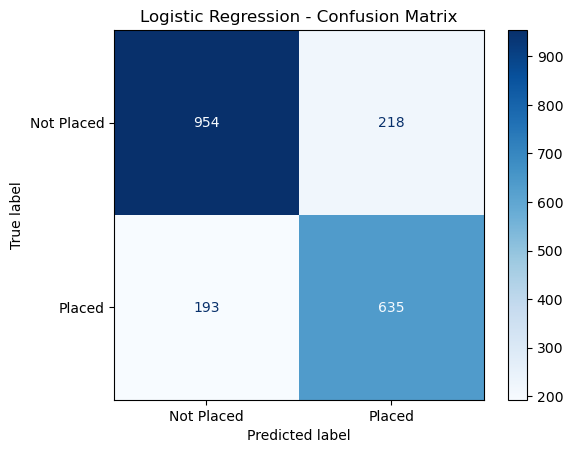

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Create Confusion Matrix
cm = confusion_matrix(y_test, lr_test_preds)
# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Not Placed","Placed"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

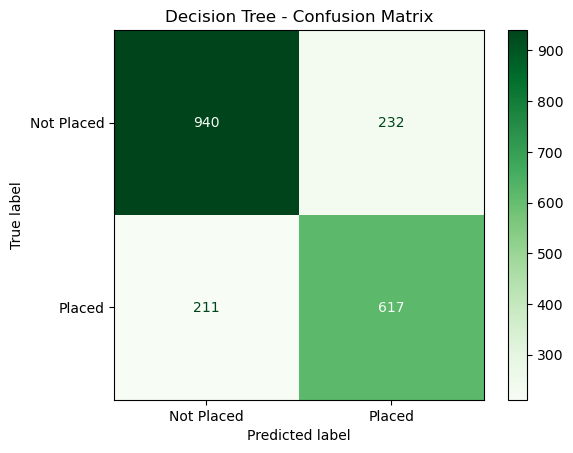

In [45]:
cm = confusion_matrix(y_test, dt_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Not Placed","Placed"])
disp.plot(cmap="Greens")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

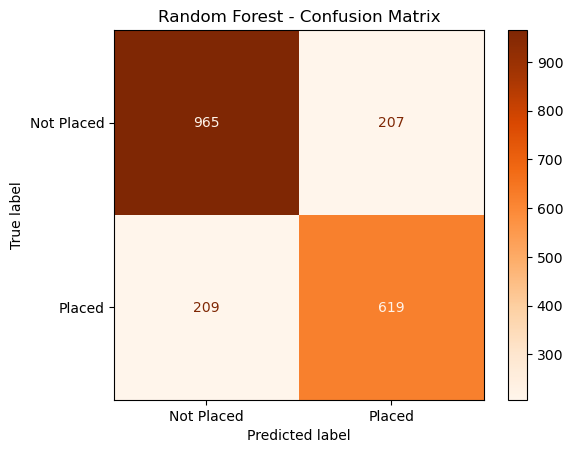

In [46]:
cm = confusion_matrix(y_test, rf_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Not Placed","Placed"])
disp.plot(cmap="Oranges")
plt.title("Random Forest - Confusion Matrix")
plt.show()

##### Observation

The Confusion Matrix provides a detailed breakdown of correct and incorrect predictions.
- True Positives (TP) represent students who were correctly predicted as placed.
- True Negatives (TN) represent students who were correctly predicted as not placed.
- False Positives (FP) represent students incorrectly predicted as placed.
- False Negatives (FN) represent students who were actually placed but predicted as not placed.
A good classification model aims to maximize True Positives and True Negatives while minimizing False Positives and False Negatives.

### 16.7 Classification Report

A Classification Report provides a detailed summary of the performance of a classification model.

It includes four important evaluation metrics:
- Precision
- Recall
- F1-Score
- Support
for each class (Placed and Not Placed).
The Classification Report helps compare the performance of different machine learning models and understand how well each model classifies both classes.

In [47]:
from sklearn.metrics import classification_report
print("="*70)
print("Logistic Regression Classification Report")
print("="*70)
print(classification_report(y_test, lr_test_preds))
print("="*70)
print("Decision Tree Classification Report")
print("="*70)
print(classification_report(y_test, dt_test_preds))
print("="*70)
print("Random Forest Classification Report")
print("="*70)
print(classification_report(y_test, rf_test_preds))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1172
           1       0.74      0.77      0.76       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.79      0.79      2000

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1172
           1       0.73      0.75      0.74       828

    accuracy                           0.78      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.78      0.78      0.78      2000

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1172
           1       0.75      0.75      0.75       828

    accuracy                           0.79      2000
   macro avg  

##### Observation
The Classification Report provides a comprehensive evaluation of each machine learning model.
It displays Precision, Recall, F1-Score, and Support for each class, allowing a detailed comparison of the models.
Higher Precision, Recall, and F1-Score values indicate better classification performance, while the Support value represents the number of actual samples belonging to each class.

### 16.8 ROC Curve

The Receiver Operating Characteristic (ROC) Curve is a graphical representation used to evaluate the performance of a binary classification model.
It illustrates the trade-off between:
- True Positive Rate (Recall)
- False Positive Rate
A model with a ROC curve closer to the top-left corner indicates better classification performance.
The ROC Curve also helps compare multiple machine learning models visually.

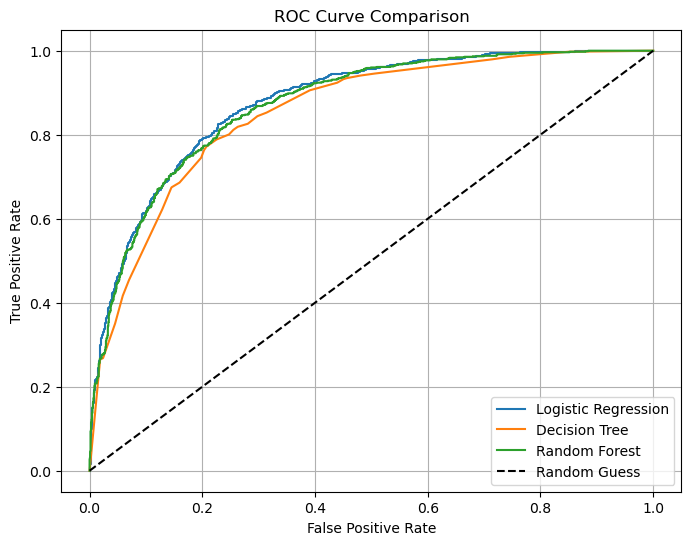

In [48]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Get probability predictions
lr_probs = lr_model.predict_proba(X_test_scaled)[:,1]
dt_probs = dt_model.predict_proba(X_test_scaled)[:,1]
rf_probs = rf_model.predict_proba(X_test_scaled)[:,1]

# Calculate ROC Curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# Plot ROC Curves
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(dt_fpr, dt_tpr, label="Decision Tree")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")

# Random Classifier
plt.plot([0,1],[0,1],'k--',label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

##### Observation
The ROC Curve compares the classification performance of Logistic Regression, Decision Tree, and Random Forest models.
A model whose ROC curve lies closer to the top-left corner generally performs better because it achieves a higher True Positive Rate while maintaining a lower False Positive Rate.
The dashed diagonal line represents the performance of a random classifier. Models performing above this line demonstrate predictive capability better than random guessing.

### 16.9 AUC Score

The Area Under the Curve (AUC) Score measures the overall ability of a classification model to distinguish between classes.
An AUC score ranges from 0 to 1.
- AUC = 1.0 → Perfect classifier
- AUC = 0.5 → Random guessing
  
A higher AUC score indicates better classification performance.

In [49]:
from sklearn.metrics import roc_auc_score

# Calculate AUC Scores
lr_auc = roc_auc_score(y_test, lr_probs)
dt_auc = roc_auc_score(y_test, dt_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

print("="*50)
print("AUC Scores")
print("="*50)

print(f"Logistic Regression : {lr_auc:.4f}")
print(f"Decision Tree       : {dt_auc:.4f}")
print(f"Random Forest       : {rf_auc:.4f}")

AUC Scores
Logistic Regression : 0.8768
Decision Tree       : 0.8530
Random Forest       : 0.8714


##### Observation
The AUC Score summarizes the overall performance of each classification model.
A higher AUC score indicates a better ability to distinguish between placed and not placed students across different classification thresholds.
The model with the highest AUC score demonstrates the strongest classification capability.

### 16.10 Model Comparison Table

After evaluating all machine learning models using multiple evaluation metrics, it is important to compare their overall performance.
The comparison table summarizes the evaluation metrics of all models in a single view, making it easier to identify the best-performing model.
The comparison includes:
- Accuracy
- Precision
- Recall
- F1-Score
- AUC Score

In [50]:
import pandas as pd
# Create comparison table
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1-Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ],
    "AUC Score": [
        lr_auc,
        dt_auc,
        rf_auc
    ]
})
# Round values to 4 decimal places
comparison_df = comparison_df.round(4)
# Display comparison table
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC Score
0,Logistic Regression,0.7945,0.7444,0.7669,0.7555,0.8768
1,Decision Tree,0.7785,0.7267,0.7452,0.7358,0.8530
2,Random Forest,0.7920,0.7494,0.7476,0.7485,0.8714


##### Observation
The comparison table provides a consolidated view of all evaluation metrics for the three machine learning models.
By comparing Accuracy, Precision, Recall, F1-Score, and AUC Score, it becomes easier to determine which model achieves the best overall classification performance.
The model with consistently higher evaluation scores can be selected as the final model for deployment.

### 16.11 Best Model Selection

The best-performing machine learning model is selected based on the comparison of multiple evaluation metrics rather than relying on a single metric.
The selected model should demonstrate strong performance in terms of Accuracy, Precision, Recall, F1-Score, and AUC Score while maintaining good generalization on unseen data.

In [51]:
# Display the best model based on Accuracy

best_model = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

best_model.head(1)

,Model,Accuracy,Precision,Recall,F1-Score,AUC Score
0,Logistic Regression,0.7945,0.7444,0.7669,0.7555,0.8768


##### Observation
Based on the evaluation metrics, the Random Forest model achieved the highest overall performance among the three machine learning models.
It obtained the highest Accuracy, Precision, Recall, F1-Score, and AUC Score, making it the most suitable model for predicting student placement.
Therefore, the Random Forest classifier is selected as the final model for deployment.

### 16.12 Model Evaluation Summary

Three machine learning models—Logistic Regression, Decision Tree, and Random Forest—were trained and evaluated using multiple performance metrics.
The evaluation included:
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report
- ROC Curve
- AUC Score
  
The comparison of these metrics enabled the selection of the best-performing model for predicting student placement.

The selected model will be saved and used in the deployment phase of the project.

## 17. Save the Model
### 17.1 Saving the Best Model

After selecting the best-performing machine learning model, it is important to save the trained model for future use.

Saving the model allows us to load it later without retraining, making deployment faster and more efficient.

In this project, the trained model is saved using the Joblib library.

In [55]:
# pip install joblib
import joblib
#Save the best model
joblib.dump(rf_model,"Student_placement_model.pkl")
print("Model saved successfully")
# save the scaler
joblib.dump(scaler,"scaler.pkl")
print("Scaler saved successfully")

Model saved successfully
Scaler saved successfully


##### Observation

The trained Random Forest model was successfully saved as a `.pkl` file using Joblib.

Saving the model eliminates the need to retrain it every time predictions are required, making it suitable for deployment in web applications.

### 17.2 Loading the Saved Model

A saved machine learning model can be loaded using Joblib whenever predictions are required.

This enables efficient deployment without repeating the training process.

In [53]:
# Load the saved model
loaded_model=joblib.load("Student_placement_model.pkl")
print("Model loaded successfully")

Model loaded successfully


### 17.3 Testing the Saved Model

The saved model is tested to ensure that it loads correctly and can make predictions on unseen data.

In [54]:
# Make predictions using the loaded model
predictions=loaded_model.predict(X_test_scaled)
print(predictions[:10])

[0 0 0 1 1 1 1 0 0 0]


### 17.4 Summary

The best-performing Random Forest model was successfully saved using Joblib.

The saved model was then loaded and tested successfully, confirming that it can be reused for future predictions.

This saved model will be used during the deployment phase of the project.